# Markowitz Portfolio Optimization 
## Eli Lilly (LLY), TSMC (TSM), Schneider Electric (SU.PA)

this notebook implements the **Modern Portofolio Theory** developed by Harry Markowitz (Nobel Prize 1990)

We use  2 years of real historical data find the optimal allocation between 3 assets that maximizes the **Sharpe Ratio** the best return per unit of risk.


In [1]:
import warnings
warnings.filterwarnings("ignore")
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

tickers = ["LLY", "TSM", "SU.PA"]
data = yf.download(tickers, period="2y")["Close"]
data = data.dropna()

print(f"Data downloaded: {len(data)} trading days")
data.head()

[*********************100%***********************]  3 of 3 completed

Data downloaded: 496 trading days


Ticker,LLY,SU.PA,TSM
Date,,,
2024-09-11,908.173218,212.837112,165.961929
2024-09-12,922.108154,218.785507,167.748749
2024-09-13,910.954224,219.752731,168.795746
2024-09-16,910.786499,219.704376,165.449219
2024-09-17,893.666260,222.799484,163.756363


## Returns and Risk Analysis

In [2]:
returns = data.pct_change().dropna()

ann_returns = returns.mean() * 252
ann_volatility = returns.std() * np.sqrt(252)

print("Annualized Returns:")
print(ann_returns.round(4))
print("\nAnnualized Volatility:")
print(ann_volatility.round(4))

Annualized Returns:
Ticker
LLY      0.1792
SU.PA    0.2171
TSM      0.5750
dtype: float64

Annualized Volatility:
Ticker
LLY      0.3761
SU.PA    0.3400
TSM      0.4160
dtype: float64


## Correlation Analysis

In [3]:
correlation_matrix = returns.corr()
correlation_matrix.round(2)

Ticker,LLY,SU.PA,TSM
Ticker,,,
LLY,1.00,-0.04,0.06
SU.PA,-0.04,1.00,0.48
TSM,0.06,0.48,1.00


## Monte Carlo Simulation — 10,000 Portfolios

In [4]:
cov_matrix = returns.cov() * 252

n_portfolios = 10000
portfolio_returns = []
portfolio_volatilities = []
portfolio_weights = []

for i in range(n_portfolios):
    weights = np.random.random(3)
    weights = weights / np.sum(weights)
    port_return = np.sum(weights * returns.mean() * 252)
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    portfolio_returns.append(port_return)
    portfolio_volatilities.append(port_volatility)
    portfolio_weights.append(weights)

print(f"Simulation complete: {n_portfolios} portfolios generated")

Simulation complete: 10000 portfolios generated


## Efficient Frontier

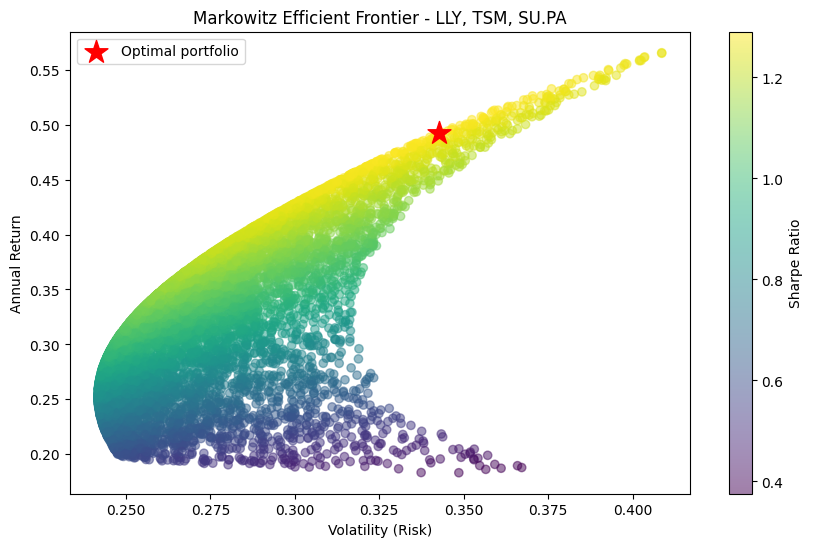

In [5]:
sharpe_ratios = [(r - 0.05) / v for r, v in zip(portfolio_returns, portfolio_volatilities)]
best_idx = sharpe_ratios.index(max(sharpe_ratios))
best_weights = portfolio_weights[best_idx]

plt.figure(figsize=(10, 6))
scatter = plt.scatter(portfolio_volatilities, portfolio_returns,
                      c=sharpe_ratios, cmap="viridis", alpha=0.5)
plt.colorbar(scatter, label="Sharpe Ratio")
plt.scatter(portfolio_volatilities[best_idx], portfolio_returns[best_idx],
            color="red", marker="*", s=300, label="Optimal portfolio")
plt.xlabel("Volatility (Risk)")
plt.ylabel("Annual Return")
plt.title("Markowitz Efficient Frontier - LLY, TSM, SU.PA")
plt.legend()
plt.show()

## Optimal Portfolio

In [6]:
print("Optimal Portfolio (highest Sharpe Ratio):")
print("-" * 45)
print(f"Eli Lilly:           {best_weights[0]*100:.2f}%")
print(f"TSMC:                {best_weights[1]*100:.2f}%")
print(f"Schneider Electric:  {best_weights[2]*100:.2f}%")
print(f"Expected Return:     {portfolio_returns[best_idx]*100:.2f}%")
print(f"Volatility:          {portfolio_volatilities[best_idx]*100:.2f}%")
print(f"Sharpe Ratio:        {max(sharpe_ratios):.2f}")

Optimal Portfolio (highest Sharpe Ratio):
---------------------------------------------
Eli Lilly:           20.35%
TSMC:                0.59%
Schneider Electric:  79.06%
Expected Return:     49.24%
Volatility:          34.28%
Sharpe Ratio:        1.29
